# Social Vulnerability Index (SVI) and Multi-Hazard Risk Assessment for Jakarta

## Implementation Notebook

This notebook implements the comprehensive SVI and Multi-Hazard Risk Assessment plan for Jakarta at the kelurahan level.

**References:**
- PMC Research: https://pmc.ncbi.nlm.nih.gov/articles/PMC11999302/
- Natural Hazards Paper: https://nhess.copernicus.org/articles/18/3363/2018/

**Implementation Plan:** `docs/SVI_MultiHazard_Implementation_Plan.md`

---

## Phase 1: Setup and Data Preparation

### Step 1.1: Import Required Libraries and Setup

In [3]:
# Core data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point, Polygon
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium import plugins

# Statistical analysis
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Utilities
import os
import glob
from pathlib import Path
import json
from datetime import datetime
import time

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8')

print("✅ All libraries imported successfully!")
print(f"📅 Notebook started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Notebook started at: 2025-08-18 19:24:53


### Step 1.2: Define Paths and Configuration

In [4]:
# Project paths
BASE_PATH = Path('/Users/nurfaldi/hack4resilient/clean_repo/Barunah-Hack4Resilientjakarta2025')
DATA_PATH = BASE_PATH / 'data'
METADATA_PATH = DATA_PATH / 'metadata'
OUTPUT_PATH = BASE_PATH / 'results' / 'svi_multihazard'
PLOTS_PATH = OUTPUT_PATH / 'plots'
MAPS_PATH = OUTPUT_PATH / 'maps'

# Create output directories
for path in [OUTPUT_PATH, PLOTS_PATH, MAPS_PATH]:
    path.mkdir(parents=True, exist_ok=True)

# Configuration
CONFIG = {
    'target_crs': 'EPSG:32748',  # UTM Zone 48S for Indonesia
    'analysis_years': list(range(2016, 2025)),
    'latest_year': 2024,
    'svi_weights': {
        'sensitivity': 0.25,
        'adaptive_capacity': 0.40,
        'exposure': 0.35
    },
    'hazard_weights': {
        'flood': 0.50,
        'heat': 0.30,
        'subsidence': 0.20
    },
    'raster_resolution': 250  # meters
}

print("📁 Project Structure:")
print(f"   Data Path: {DATA_PATH}")
print(f"   Output Path: {OUTPUT_PATH}")
print(f"   Target CRS: {CONFIG['target_crs']}")
print(f"   Analysis Period: {CONFIG['analysis_years'][0]}-{CONFIG['analysis_years'][-1]}")
print("\n✅ Paths and configuration set!")

📁 Project Structure:
   Data Path: /Users/nurfaldi/hack4resilient/clean_repo/Barunah-Hack4Resilientjakarta2025/data
   Output Path: /Users/nurfaldi/hack4resilient/clean_repo/Barunah-Hack4Resilientjakarta2025/results/svi_multihazard
   Target CRS: EPSG:32748
   Analysis Period: 2016-2024

✅ Paths and configuration set!


### Step 1.3: Load and Examine Metadata

In [5]:
# Load the enhanced metadata
metadata_file = METADATA_PATH / 'Enhanced_Complete_Dataset_Metadata.csv'
metadata_df = pd.read_csv(metadata_file)

print("📊 METADATA OVERVIEW")
print("=" * 50)
print(f"Total records: {len(metadata_df):,}")
print(f"Unique datasets: {metadata_df['Dataset_Name'].nunique()}")
print(f"Unique folders: {metadata_df['Folder_Name'].nunique()}")

# Show data type distribution
print("\n📈 Data Types:")
print(metadata_df['Data_Type'].value_counts())

# Show vulnerability relevance scores
print("\n🎯 Vulnerability Relevance Distribution:")
vuln_cols = ['Vulnerability_Relevance', 'Exposure_Relevance', 'Adaptive_Capacity_Relevance']
for col in vuln_cols:
    print(f"{col}:")
    print(metadata_df[col].value_counts())
    print()

# Display first few records for inspection
print("\n📋 Sample Records:")
display_cols = ['Dataset_Name', 'Column_Name', 'Column_Description', 
                'Vulnerability_Relevance', 'Data_Type', 'Spatial_Type']
metadata_df[display_cols].head(10)

📊 METADATA OVERVIEW
Total records: 1,607
Unique datasets: 278
Unique folders: 28

📈 Data Types:
Data_Type
Vector     1208
Tabular     200
Raster      199
Name: count, dtype: int64

🎯 Vulnerability Relevance Distribution:
Vulnerability_Relevance:
Vulnerability_Relevance
Low       1172
High       364
Medium      71
Name: count, dtype: int64

Exposure_Relevance:
Exposure_Relevance
Low       1018
High       296
Medium     293
Name: count, dtype: int64

Adaptive_Capacity_Relevance:
Adaptive_Capacity_Relevance
Low       1136
Medium     309
High       162
Name: count, dtype: int64


📋 Sample Records:


,Dataset_Name,Column_Name,Column_Description,Vulnerability_Relevance,Data_Type,Spatial_Type
0,adm_dki-jakarta,OBJECTID,Object ID,Low,Vector,Vector
1,adm_dki-jakarta,NAMOBJ,No description available,Low,Vector,Vector
2,adm_dki-jakarta,FCODE,No description available,Low,Vector,Vector
3,adm_dki-jakarta,REMARK,No description available,Low,Vector,Vector
4,adm_dki-jakarta,METADATA,No description available,Low,Vector,Vector
5,adm_dki-jakarta,SRS_ID,No description available,Low,Vector,Vector
6,adm_dki-jakarta,KDBBPS,No description available,Low,Vector,Vector
7,adm_dki-jakarta,KDCBPS,No description available,Low,Vector,Vector
8,adm_dki-jakarta,KDCPUM,No description available,Low,Vector,Vector
9,adm_dki-jakarta,KDEBPS,No description available,Low,Vector,Vector


### Step 1.4: Identify Key Datasets for SVI Analysis

In [6]:
# Filter for high-relevance indicators
high_relevance = metadata_df[
    (metadata_df['Vulnerability_Relevance'].isin(['High', 'Medium'])) |
    (metadata_df['Exposure_Relevance'].isin(['High', 'Medium'])) |
    (metadata_df['Adaptive_Capacity_Relevance'].isin(['High', 'Medium']))
]

print("🎯 HIGH-RELEVANCE INDICATORS FOR SVI")
print("=" * 60)
print(f"Total high-relevance indicators: {len(high_relevance)}")

# Group by dataset to identify key datasets
key_datasets = high_relevance.groupby('Dataset_Name').agg({
    'Column_Name': 'count',
    'Vulnerability_Relevance': lambda x: (x == 'High').sum(),
    'Exposure_Relevance': lambda x: (x == 'High').sum(),
    'Adaptive_Capacity_Relevance': lambda x: (x == 'High').sum(),
    'Data_Type': lambda x: x.iloc[0] if len(x) > 0 else 'Unknown',
    'Spatial_Type': lambda x: x.iloc[0] if len(x) > 0 else 'Unknown'
}).round(2)

key_datasets.columns = ['Total_Indicators', 'High_Vuln', 'High_Exposure', 
                       'High_Adaptive', 'Data_Type', 'Spatial_Type']
key_datasets = key_datasets.sort_values('Total_Indicators', ascending=False)

print("\n📊 Key Datasets Ranked by Indicator Count:")
print(key_datasets.head(15))

# Focus on the main comprehensive dataset
main_dataset = 'Neighborhoods_5.0'
if main_dataset in key_datasets.index:
    print(f"\n⭐ Main Dataset Identified: {main_dataset}")
    main_indicators = high_relevance[high_relevance['Dataset_Name'] == main_dataset]
    print(f"   - Total indicators: {len(main_indicators)}")
    print(f"   - High vulnerability: {(main_indicators['Vulnerability_Relevance'] == 'High').sum()}")
    print(f"   - High exposure: {(main_indicators['Exposure_Relevance'] == 'High').sum()}")
    print(f"   - High adaptive capacity: {(main_indicators['Adaptive_Capacity_Relevance'] == 'High').sum()}")
else:
    print(f"\n⚠️ Main dataset '{main_dataset}' not found in high-relevance indicators")
    print("Available datasets:")
    print(key_datasets.index.tolist()[:10])

🎯 HIGH-RELEVANCE INDICATORS FOR SVI
Total high-relevance indicators: 674

📊 Key Datasets Ranked by Indicator Count:
                              Total_Indicators  High_Vuln  High_Exposure  \
Dataset_Name                                                               
Neighborhoods_5.0                          288        208            186   
hexagons_with_data14                        85         44             52   
proportion_residential_area                  8          3              3   
socioeconomic_age_2016                       6          3              2   
socioeconomic_age_2017                       6          3              2   
socioeconomic_education_2020                 6          3              1   
socioeconomic_education_2019                 6          3              1   
socioeconomic_education_2018                 6          3              1   
socioeconomic_education_2017                 6          3              1   
socioeconomic_education_2016                 6  

### Step 1.5: Create SVI Indicator Framework

In [7]:
# Define SVI indicator framework based on available data
SVI_INDICATORS = {
    'sensitivity': {
        'description': 'Demographic and social characteristics that make populations more susceptible to harm',
        'indicators': {
            # Age-related vulnerability
            'young_population': {
                'columns': [f'AgeY{year}' for year in range(16, 25)],
                'description': 'Percentage of population under 5 years',
                'direction': 'positive',  # higher = more vulnerable
                'weight': 0.3
            },
            'elderly_population': {
                'columns': [f'AgeO{year}' for year in range(16, 25)],
                'description': 'Percentage of population over 65 years',
                'direction': 'positive',
                'weight': 0.3
            },
            # Density and social factors
            'population_density': {
                'columns': [f'PopDens{year}' for year in range(15, 25)],
                'description': 'Population density per km²',
                'direction': 'positive',
                'weight': 0.2
            },
            # Building vulnerability
            'building_age': {
                'columns': ['BldgAge'],
                'description': 'Average age of buildings',
                'direction': 'positive',
                'weight': 0.2
            }
        }
    },
    
    'adaptive_capacity': {
        'description': 'Resources and capabilities that enable populations to cope with and recover from hazards',
        'indicators': {
            # Education
            'education_level': {
                'columns': [f'LowEdu{year}' for year in range(16, 25)],
                'description': 'Percentage with low education',
                'direction': 'negative',  # higher = lower adaptive capacity
                'weight': 0.25
            },
            # Economic indicators
            'poverty_rate': {
                'columns': ['R710'],  # From poverty datasets
                'description': 'Number of people below poverty line',
                'direction': 'negative',
                'weight': 0.25
            },
            'economic_activity': {
                'columns': [f'NightLt{year}' for year in range(16, 25)],
                'description': 'Night light intensity as proxy for economic activity',
                'direction': 'positive',  # higher = better adaptive capacity
                'weight': 0.25
            },
            # Infrastructure
            'built_environment': {
                'columns': [f'BldRate{year}' for year in range(15, 25)],
                'description': 'Built-up rate indicating development level',
                'direction': 'positive',
                'weight': 0.25
            }
        }
    },
    
    'exposure': {
        'description': 'Physical location and environmental conditions that expose populations to hazards',
        'indicators': {
            # Flood exposure
            'flood_history': {
                'columns': [f'Flood{year}' for year in range(16, 25)],
                'description': 'Historical flood occurrence (binary)',
                'direction': 'positive',
                'weight': 0.4
            },
            'flood_depth': {
                'columns': [f'FloDepth{year}' for year in range(16, 25)],
                'description': 'Maximum flood depth recorded',
                'direction': 'positive',
                'weight': 0.3
            },
            # Environmental hazards
            'land_subsidence': {
                'columns': ['LandSub20', 'LandSub24'],
                'description': 'Land subsidence rate',
                'direction': 'positive',
                'weight': 0.2
            },
            # Climate exposure
            'temperature_exposure': {
                'columns': [f'LSTemp{year}' for year in range(16, 25)],
                'description': 'Land surface temperature',
                'direction': 'positive',
                'weight': 0.1
            }
        }
    }
}

# Print framework summary
print("🏗️ SVI INDICATOR FRAMEWORK")
print("=" * 50)
for dimension, info in SVI_INDICATORS.items():
    print(f"\n📊 {dimension.upper()} (Weight: {CONFIG['svi_weights'][dimension]:.0%})")
    print(f"   {info['description']}")
    
    for indicator, details in info['indicators'].items():
        print(f"\n   • {indicator.replace('_', ' ').title()}:")
        print(f"     - Description: {details['description']}")
        print(f"     - Variables: {len(details['columns'])} columns")
        print(f"     - Direction: {details['direction']} (higher values = {'more' if details['direction'] == 'positive' else 'less'} vulnerable)")
        print(f"     - Weight: {details['weight']:.0%}")

print("\n✅ SVI Framework defined!")

🏗️ SVI INDICATOR FRAMEWORK

📊 SENSITIVITY (Weight: 25%)
   Demographic and social characteristics that make populations more susceptible to harm

   • Young Population:
     - Description: Percentage of population under 5 years
     - Variables: 9 columns
     - Direction: positive (higher values = more vulnerable)
     - Weight: 30%

   • Elderly Population:
     - Description: Percentage of population over 65 years
     - Variables: 9 columns
     - Direction: positive (higher values = more vulnerable)
     - Weight: 30%

   • Population Density:
     - Description: Population density per km²
     - Variables: 10 columns
     - Direction: positive (higher values = more vulnerable)
     - Weight: 20%

   • Building Age:
     - Description: Average age of buildings
     - Variables: 1 columns
     - Direction: positive (higher values = more vulnerable)
     - Weight: 20%

📊 ADAPTIVE_CAPACITY (Weight: 40%)
   Resources and capabilities that enable populations to cope with and recover fr

---
## 🔄 CHECKPOINT 1: Setup Complete

**Summary of Progress:**
- ✅ Libraries imported and environment configured
- ✅ Project paths and directories created
- ✅ Metadata loaded and analyzed
- ✅ Key datasets identified
- ✅ SVI indicator framework defined

**Next Steps:** Load and explore the main dataset

---

## Phase 2: Data Loading and Exploration

### Step 2.1: Load Main Dataset and Administrative Boundaries

In [10]:
# Load the main neighborhoods dataset
neighborhoods_file = None
possible_paths = [
    DATA_PATH /'extracted_data'/'02 GIS Data (Neighborhood & Grid levels)'/'Neighborhoods'/'Neighborhoods_5.0.csv'
]

for path in possible_paths:
    if path.exists():
        neighborhoods_file = path
        break

if neighborhoods_file:
    print(f"📂 Loading main dataset: {neighborhoods_file}")
    df_main = pd.read_csv(neighborhoods_file)
    print(f"✅ Dataset loaded successfully!")
    
    print(f"\n📊 DATASET OVERVIEW:")
    print(f"   Rows: {len(df_main):,}")
    print(f"   Columns: {len(df_main.columns):,}")
    print(f"   Memory usage: {df_main.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    # Show basic info
    print(f"\n🏛️ Administrative levels:")
    if 'WADMKD' in df_main.columns:
        print(f"   Kelurahan (villages): {df_main['WADMKD'].nunique()}")
    if 'WADMKC' in df_main.columns:
        print(f"   Kecamatan (districts): {df_main['WADMKC'].nunique()}")
    if 'WADMKK' in df_main.columns:
        print(f"   Kota (cities): {df_main['WADMKK'].nunique()}")
        
    print(f"\n📋 First few columns:")
    print(df_main.columns.tolist()[:20])
    
else:
    print("❌ Main dataset not found. Please check the file path.")
    print("Searched locations:")
    for path in possible_paths:
        print(f"   - {path} {'✅' if path.exists() else '❌'}")

📂 Loading main dataset: /Users/nurfaldi/hack4resilient/clean_repo/Barunah-Hack4Resilientjakarta2025/data/extracted_data/02 GIS Data (Neighborhood & Grid levels)/Neighborhoods/Neighborhoods_5.0.csv
✅ Dataset loaded successfully!

📊 DATASET OVERVIEW:
   Rows: 261
   Columns: 194
   Memory usage: 0.5 MB

🏛️ Administrative levels:
   Kelurahan (villages): 261
   Kecamatan (districts): 42
   Kota (cities): 5

📋 First few columns:
['OBJECTID_1', 'WADMKC', 'WADMKD', 'WADMKK', 'FID_', 'OBJECTID_2', 'WADMKC_1', 'WADMKD_1', 'WADMKK_1', 'UID', 'Topo', 'Rain16', 'Rain17', 'Rain18', 'Rain19', 'Rain20', 'Rain21', 'Rain22', 'Rain23', 'Rain24']


In [ ]:
# Load administrative boundaries (kelurahan level)
admin_boundary_file = None
possible_admin_paths = [
    DATA_PATH /'extracted_data'/'01 Area of Interest'/ 'Kelurahan' / 'adm_dki-jakarta_kelurahan.shp',
]

for path in possible_admin_paths:
    if path.exists():
        admin_boundary_file = path
        break

if admin_boundary_file:
    print(f"🗺️ Loading administrative boundaries: {admin_boundary_file}")
    gdf_admin = gpd.read_file(admin_boundary_file)
    
    # Reproject to target CRS
    if gdf_admin.crs != CONFIG['target_crs']:
        print(f"🔄 Reprojecting from {gdf_admin.crs} to {CONFIG['target_crs']}")
        gdf_admin = gdf_admin.to_crs(CONFIG['target_crs'])
    
    print(f"✅ Boundaries loaded successfully!")
    print(f"\n🗺️ BOUNDARY OVERVIEW:")
    print(f"   Features: {len(gdf_admin):,}")
    print(f"   CRS: {gdf_admin.crs}")
    print(f"   Bounds: {gdf_admin.bounds.iloc[0].values}")
    
    print(f"\n📋 Available columns:")
    print(gdf_admin.columns.tolist())
    
    # Show sample data
    if 'WADMKD' in gdf_admin.columns:
        print(f"\n🏛️ Sample kelurahan names:")
        print(gdf_admin['WADMKD'].head(10).values)
    
else:
    print("❌ Administrative boundaries not found. Please check the file path.")
    print("Searched locations:")
    for path in possible_admin_paths:
        print(f"   - {path} {'✅' if path.exists() else '❌'}")

🗺️ Loading administrative boundaries: /Users/nurfaldi/hack4resilient/clean_repo/Barunah-Hack4Resilientjakarta2025/data/extracted_data/01 Area of Interest/Kelurahan/adm_dki-jakarta_kelurahan.shp
🔄 Reprojecting from EPSG:4326 to EPSG:32748
✅ Boundaries loaded successfully!

🗺️ BOUNDARY OVERVIEW:
   Features: 261
   CRS: EPSG:32748
   Bounds: [ 705558.04508391 9315646.24017315  706915.78657    9317533.39866163]

📋 Available columns:
['OBJECTID', 'WADMKC', 'WADMKD', 'WADMKK', 'geometry']

🏛️ Sample kelurahan names:
['CEMPAKA PUTIH BARAT' 'RAWASARI' 'MENTENG' 'PEGANGSAAN' 'CIKINI'
 'GONDANGDIA' 'KEBON SIRIH' 'GELORA' 'BENDUNGAN HILIR' 'KARET TENGSIN']


### Step 2.2: Data Quality Assessment and Visualization

🔍 DATA QUALITY ASSESSMENT

📊 Missing Data Summary:
   Total columns: 194
   Columns with missing data: 3
   Average missing percentage: 0.01%

🚨 Top 10 columns with missing data:
          Missing_Count  Missing_Percent
FRI16                 1         0.383142
FVI16                 1         0.383142
LowEdu16              1         0.383142


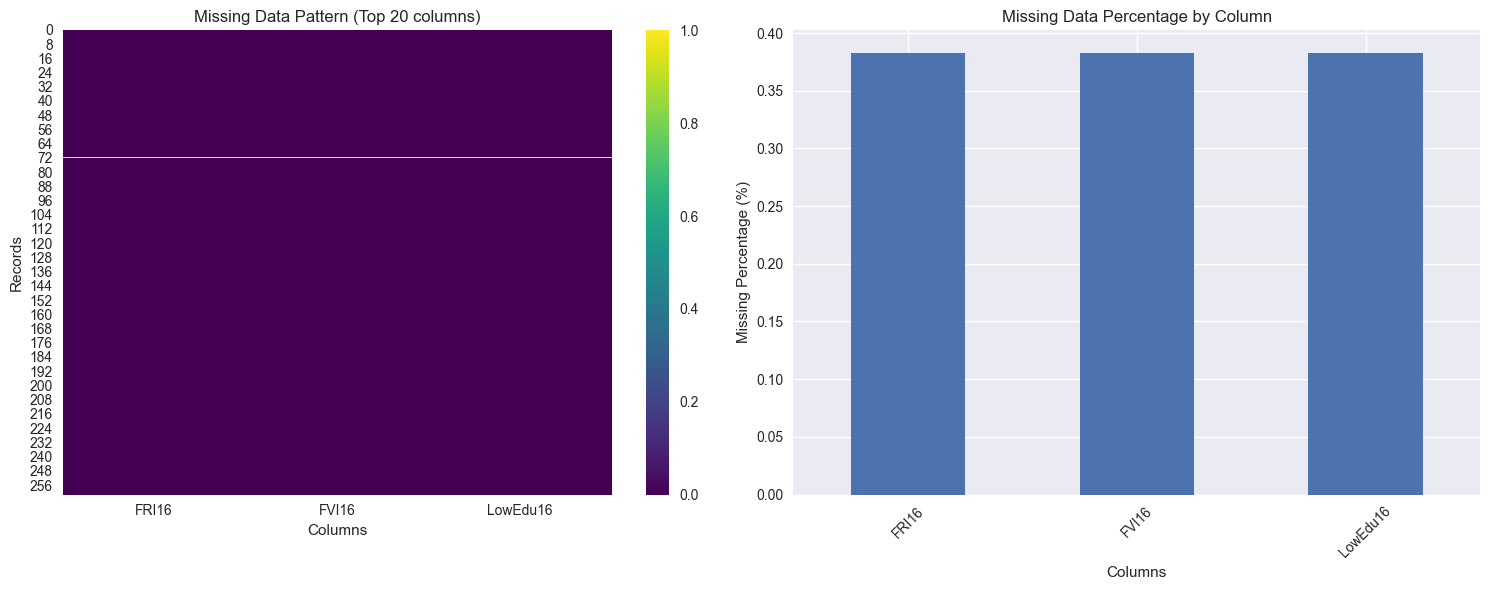

In [12]:
# Data quality assessment
if 'df_main' in locals():
    print("🔍 DATA QUALITY ASSESSMENT")
    print("=" * 50)
    
    # Missing data analysis
    missing_data = df_main.isnull().sum()
    missing_pct = (missing_data / len(df_main)) * 100
    missing_summary = pd.DataFrame({
        'Missing_Count': missing_data,
        'Missing_Percent': missing_pct
    }).sort_values('Missing_Percent', ascending=False)
    
    print(f"\n📊 Missing Data Summary:")
    print(f"   Total columns: {len(df_main.columns)}")
    print(f"   Columns with missing data: {(missing_data > 0).sum()}")
    print(f"   Average missing percentage: {missing_pct.mean():.2f}%")
    
    # Show top columns with missing data
    if missing_summary['Missing_Percent'].max() > 0:
        print(f"\n🚨 Top 10 columns with missing data:")
        print(missing_summary[missing_summary['Missing_Percent'] > 0].head(10))
    else:
        print(f"\n✅ No missing data found!")
    
    # Visualize missing data
    if missing_summary['Missing_Percent'].max() > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Missing data heatmap (top 20 columns)
        top_missing = missing_summary[missing_summary['Missing_Percent'] > 0].head(20)
        if len(top_missing) > 0:
            missing_cols = top_missing.index.tolist()
            sns.heatmap(df_main[missing_cols].isnull(), 
                       cbar=True, ax=ax1, cmap='viridis')
            ax1.set_title('Missing Data Pattern (Top 20 columns)')
            ax1.set_xlabel('Columns')
            ax1.set_ylabel('Records')
        
        # Missing data bar chart
        top_missing['Missing_Percent'].plot(kind='bar', ax=ax2)
        ax2.set_title('Missing Data Percentage by Column')
        ax2.set_xlabel('Columns')
        ax2.set_ylabel('Missing Percentage (%)')
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig(PLOTS_PATH / 'data_quality_missing.png', dpi=300, bbox_inches='tight')
        plt.show()
    
else:
    print("❌ Main dataset not available for quality assessment")

### Step 2.3: Explore Available SVI Indicators

In [13]:
# Check availability of SVI indicators in the dataset
if 'df_main' in locals():
    print("🎯 SVI INDICATOR AVAILABILITY CHECK")
    print("=" * 60)
    
    available_indicators = {}
    missing_indicators = {}
    
    for dimension, info in SVI_INDICATORS.items():
        print(f"\n📊 {dimension.upper()}:")
        available_indicators[dimension] = {}
        missing_indicators[dimension] = {}
        
        for indicator, details in info['indicators'].items():
            available_cols = [col for col in details['columns'] if col in df_main.columns]
            missing_cols = [col for col in details['columns'] if col not in df_main.columns]
            
            print(f"\n   • {indicator.replace('_', ' ').title()}:")
            print(f"     Available: {len(available_cols)}/{len(details['columns'])} columns")
            
            if available_cols:
                available_indicators[dimension][indicator] = {
                    'columns': available_cols,
                    'details': details
                }
                print(f"     ✅ {available_cols[:3]}{'...' if len(available_cols) > 3 else ''}")
                
                # Show basic stats for first available column
                sample_col = available_cols[0]
                sample_data = df_main[sample_col].dropna()
                if len(sample_data) > 0:
                    print(f"     📈 Stats ({sample_col}): min={sample_data.min():.2f}, "
                          f"mean={sample_data.mean():.2f}, max={sample_data.max():.2f}")
            
            if missing_cols:
                missing_indicators[dimension][indicator] = missing_cols
                print(f"     ❌ Missing: {missing_cols[:3]}{'...' if len(missing_cols) > 3 else ''}")
    
    # Summary statistics
    total_available = sum(len(dim) for dim in available_indicators.values())
    total_expected = sum(len(info['indicators']) for info in SVI_INDICATORS.values())
    
    print(f"\n📈 AVAILABILITY SUMMARY:")
    print(f"   Available indicators: {total_available}/{total_expected}")
    print(f"   Coverage: {total_available/total_expected:.1%}")
    
    for dimension in SVI_INDICATORS.keys():
        dim_available = len(available_indicators[dimension])
        dim_total = len(SVI_INDICATORS[dimension]['indicators'])
        print(f"   {dimension.capitalize()}: {dim_available}/{dim_total} ({dim_available/dim_total:.1%})")

else:
    print("❌ Main dataset not available for indicator check")

🎯 SVI INDICATOR AVAILABILITY CHECK

📊 SENSITIVITY:

   • Young Population:
     Available: 9/9 columns
     ✅ ['AgeY16', 'AgeY17', 'AgeY18']...
     📈 Stats (AgeY16): min=0.05, mean=0.08, max=0.10

   • Elderly Population:
     Available: 9/9 columns
     ✅ ['AgeO16', 'AgeO17', 'AgeO18']...
     📈 Stats (AgeO16): min=0.02, mean=0.05, max=0.13

   • Population Density:
     Available: 10/10 columns
     ✅ ['PopDens15', 'PopDens16', 'PopDens17']...
     📈 Stats (PopDens15): min=826.74, mean=22697.72, max=91797.46

   • Building Age:
     Available: 1/1 columns
     ✅ ['BldgAge']
     📈 Stats (BldgAge): min=39.69, mean=90.48, max=310.56

📊 ADAPTIVE_CAPACITY:

   • Education Level:
     Available: 9/9 columns
     ✅ ['LowEdu16', 'LowEdu17', 'LowEdu18']...
     📈 Stats (LowEdu16): min=0.11, mean=0.25, max=0.42

   • Poverty Rate:
     Available: 0/1 columns
     ❌ Missing: ['R710']

   • Economic Activity:
     Available: 9/9 columns
     ✅ ['NightLt16', 'NightLt17', 'NightLt18']...
     📈 

### Step 2.4: Visualize Geographic Distribution

🗺️ CREATING GEOGRAPHIC OVERVIEW


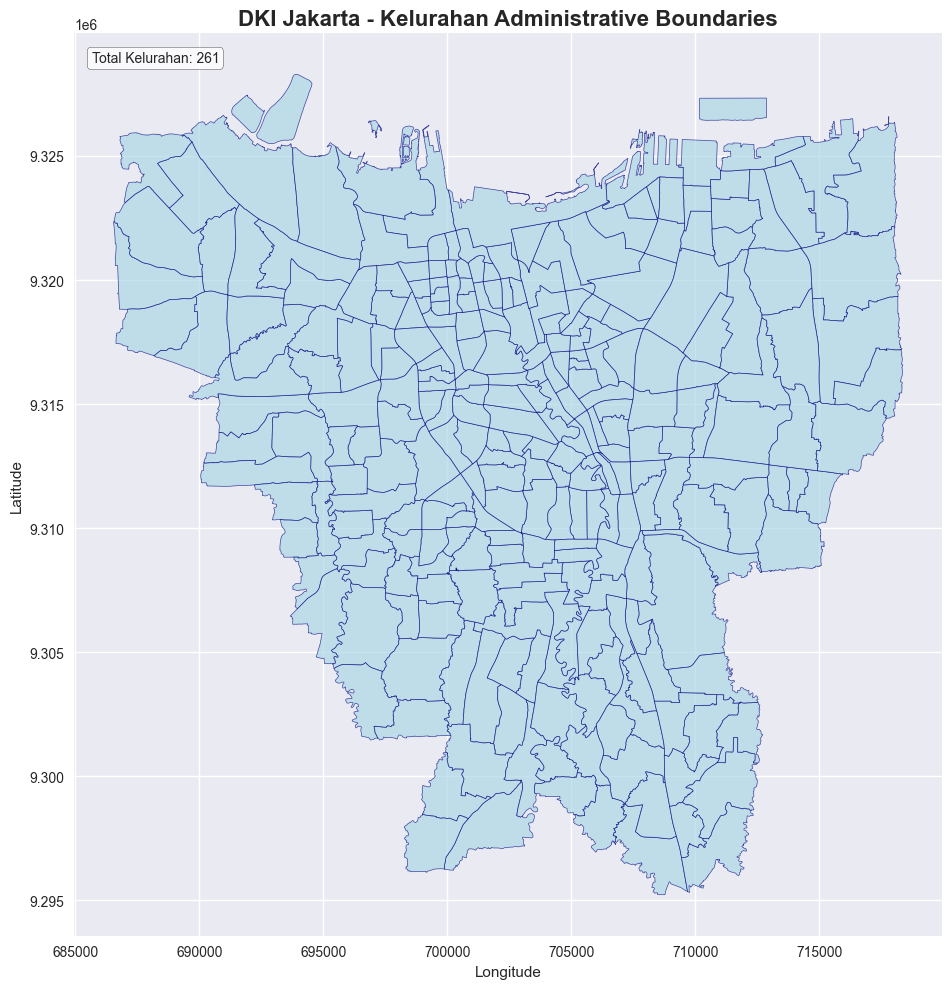


🌐 Creating interactive map...
✅ Interactive map saved to: /Users/nurfaldi/hack4resilient/clean_repo/Barunah-Hack4Resilientjakarta2025/results/svi_multihazard/maps/jakarta_interactive_boundaries.html

📊 Geographic Statistics:
   Total area: 650.8 km²
   Average kelurahan area: 2.49 km²
   Largest kelurahan: 15.63 km²
   Smallest kelurahan: 0.27 km²


In [14]:
# Create geographic visualization of Jakarta kelurahan
if 'gdf_admin' in locals():
    print("🗺️ CREATING GEOGRAPHIC OVERVIEW")
    print("=" * 40)
    
    # Basic map of Jakarta
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plot kelurahan boundaries
    gdf_admin.plot(ax=ax, 
                   facecolor='lightblue', 
                   edgecolor='navy', 
                   alpha=0.7,
                   linewidth=0.5)
    
    ax.set_title('DKI Jakarta - Kelurahan Administrative Boundaries', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude') 
    
    # Add some basic annotations
    ax.text(0.02, 0.98, f'Total Kelurahan: {len(gdf_admin)}', 
            transform=ax.transAxes, 
            bbox=dict(boxstyle="round", facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(PLOTS_PATH / 'jakarta_administrative_boundaries.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Interactive map with Folium
    print("\n🌐 Creating interactive map...")
    
    # Calculate center point
    bounds = gdf_admin.bounds
    center_lat = (bounds.miny.min() + bounds.maxy.max()) / 2
    center_lon = (bounds.minx.min() + bounds.maxx.max()) / 2
    
    # Convert to WGS84 for folium
    gdf_web = gdf_admin.to_crs('EPSG:4326')
    
    # Create interactive map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap'
    )
    
    # Add kelurahan boundaries
    folium.GeoJson(
        gdf_web,
        style_function=lambda x: {
            'fillColor': 'lightblue',
            'color': 'navy',
            'weight': 1,
            'fillOpacity': 0.6
        },
        popup=folium.GeoJsonPopup(
            fields=['WADMKD', 'WADMKC'] if 'WADMKD' in gdf_web.columns else None,
            aliases=['Kelurahan:', 'Kecamatan:'] if 'WADMKD' in gdf_web.columns else None
        )
    ).add_to(m)
    
    # Save interactive map
    m.save(MAPS_PATH / 'jakarta_interactive_boundaries.html')
    print(f"✅ Interactive map saved to: {MAPS_PATH / 'jakarta_interactive_boundaries.html'}")
    
    # Display basic statistics
    print(f"\n📊 Geographic Statistics:")
    gdf_admin['area_km2'] = gdf_admin.geometry.area / 1e6  # Convert to km²
    print(f"   Total area: {gdf_admin['area_km2'].sum():.1f} km²")
    print(f"   Average kelurahan area: {gdf_admin['area_km2'].mean():.2f} km²")
    print(f"   Largest kelurahan: {gdf_admin['area_km2'].max():.2f} km²")
    print(f"   Smallest kelurahan: {gdf_admin['area_km2'].min():.2f} km²")

else:
    print("❌ Administrative boundaries not available for mapping")

---
## 🔄 CHECKPOINT 2: Data Loading Complete

**Summary of Progress:**
- ✅ Main dataset loaded and examined
- ✅ Administrative boundaries loaded
- ✅ Data quality assessed
- ✅ SVI indicators availability checked
- ✅ Geographic overview created

**Next Steps:** Process and calculate SVI indicators

---

## Phase 3: SVI Indicator Processing and Calculation

### Step 3.1: Data Preprocessing and Indicator Aggregation

In [15]:
# Process and aggregate SVI indicators
if 'df_main' in locals() and 'available_indicators' in locals():
    print("⚙️ PROCESSING SVI INDICATORS")
    print("=" * 50)
    
    # Create processed dataframe
    df_svi = df_main.copy()
    
    # Initialize indicator scores
    indicator_scores = {}
    
    for dimension, indicators in available_indicators.items():
        print(f"\n📊 Processing {dimension.upper()} indicators:")
        indicator_scores[dimension] = {}
        
        for indicator, info in indicators.items():
            columns = info['columns']
            details = info['details']
            
            print(f"\n   • {indicator.replace('_', ' ').title()}:")
            print(f"     Processing {len(columns)} columns...")
            
            # Handle different aggregation strategies
            if len(columns) == 1:
                # Single column - use as is
                raw_values = df_svi[columns[0]].copy()
                print(f"     Using single column: {columns[0]}")
                
            elif len(columns) > 1:
                # Multiple columns - use most recent or average
                available_data = df_svi[columns].dropna(axis=1, how='all')
                
                if len(available_data.columns) > 0:
                    if 'year' in indicator or any(str(year) in col for col in columns for year in range(2020, 2025)):
                        # Time series data - use most recent
                        most_recent_col = available_data.columns[-1]
                        raw_values = available_data[most_recent_col].copy()
                        print(f"     Using most recent: {most_recent_col}")
                    else:
                        # Non-temporal data - use average
                        raw_values = available_data.mean(axis=1)
                        print(f"     Using average of {len(available_data.columns)} columns")
                else:
                    raw_values = pd.Series(np.nan, index=df_svi.index)
                    print(f"     ⚠️ No valid data found")
            
            # Store raw values
            indicator_scores[dimension][f'{indicator}_raw'] = raw_values
            
            # Calculate normalized scores (z-score then min-max)
            if raw_values.notna().sum() > 1:  # Need at least 2 valid values
                # Z-score normalization
                z_scores = zscore(raw_values.dropna())
                normalized = pd.Series(np.nan, index=raw_values.index)
                normalized[raw_values.notna()] = z_scores
                
                # Min-max scaling to 0-1 range
                if normalized.notna().sum() > 0:
                    min_val, max_val = normalized.min(), normalized.max()
                    if max_val > min_val:
                        normalized = (normalized - min_val) / (max_val - min_val)
                    
                    # Reverse direction if negative indicator
                    if details['direction'] == 'negative':
                        normalized = 1 - normalized
                    
                    indicator_scores[dimension][indicator] = normalized
                    
                    print(f"     ✅ Normalized: min={normalized.min():.3f}, "
                          f"mean={normalized.mean():.3f}, max={normalized.max():.3f}")
                else:
                    print(f"     ❌ Normalization failed - insufficient valid data")
            else:
                print(f"     ❌ Insufficient data for normalization")
    
    print(f"\n✅ Indicator processing complete!")
    
else:
    print("❌ Required data not available for indicator processing")

⚙️ PROCESSING SVI INDICATORS

📊 Processing SENSITIVITY indicators:

   • Young Population:
     Processing 9 columns...
     Using average of 9 columns
     ✅ Normalized: min=0.000, mean=0.581, max=1.000

   • Elderly Population:
     Processing 9 columns...
     Using average of 9 columns
     ✅ Normalized: min=0.000, mean=0.256, max=1.000

   • Population Density:
     Processing 10 columns...
     Using average of 10 columns
     ✅ Normalized: min=0.000, mean=0.245, max=1.000

   • Building Age:
     Processing 1 columns...
     Using single column: BldgAge
     ✅ Normalized: min=0.000, mean=0.188, max=1.000

📊 Processing ADAPTIVE_CAPACITY indicators:

   • Education Level:
     Processing 9 columns...
     Using average of 9 columns
     ✅ Normalized: min=0.000, mean=0.578, max=1.000

   • Economic Activity:
     Processing 9 columns...
     Using average of 9 columns
     ✅ Normalized: min=0.000, mean=0.445, max=1.000

   • Built Environment:
     Processing 10 columns...
     Usi

### Step 3.2: Calculate Dimension Scores

In [16]:
# Calculate dimension scores by combining indicators
if 'indicator_scores' in locals():
    print("🧮 CALCULATING DIMENSION SCORES")
    print("=" * 40)
    
    dimension_scores = {}
    
    for dimension, indicators in indicator_scores.items():
        print(f"\n📊 {dimension.upper()} Dimension:")
        
        # Get normalized indicators (exclude raw values)
        normalized_indicators = {k: v for k, v in indicators.items() 
                               if not k.endswith('_raw') and isinstance(v, pd.Series)}
        
        if normalized_indicators:
            print(f"   Available indicators: {list(normalized_indicators.keys())}")
            
            # Get weights for available indicators
            weights = {}
            total_weight = 0
            
            for indicator in normalized_indicators.keys():
                if indicator in SVI_INDICATORS[dimension]['indicators']:
                    weight = SVI_INDICATORS[dimension]['indicators'][indicator]['weight']
                    weights[indicator] = weight
                    total_weight += weight
            
            # Normalize weights to sum to 1
            if total_weight > 0:
                weights = {k: v/total_weight for k, v in weights.items()}
                print(f"   Normalized weights: {weights}")
                
                # Calculate weighted average
                dimension_score = pd.Series(0.0, index=df_svi.index)
                valid_data_count = pd.Series(0, index=df_svi.index)
                
                for indicator, weight in weights.items():
                    if indicator in normalized_indicators:
                        indicator_data = normalized_indicators[indicator]
                        valid_mask = indicator_data.notna()
                        
                        dimension_score[valid_mask] += (indicator_data[valid_mask] * weight)
                        valid_data_count[valid_mask] += weight
                
                # Adjust for missing data
                dimension_score = dimension_score / valid_data_count
                dimension_score = dimension_score.fillna(np.nan)
                
                dimension_scores[dimension] = dimension_score
                
                # Statistics
                valid_count = dimension_score.notna().sum()
                print(f"   ✅ Calculated for {valid_count}/{len(df_svi)} kelurahan")
                if valid_count > 0:
                    print(f"   📈 Stats: min={dimension_score.min():.3f}, "
                          f"mean={dimension_score.mean():.3f}, max={dimension_score.max():.3f}")
                    print(f"   📊 Std: {dimension_score.std():.3f}")
            else:
                print(f"   ❌ No valid weights found")
        else:
            print(f"   ❌ No valid indicators found")
    
    print(f"\n✅ Dimension score calculation complete!")
    print(f"   Dimensions calculated: {list(dimension_scores.keys())}")

else:
    print("❌ Indicator scores not available for dimension calculation")

🧮 CALCULATING DIMENSION SCORES

📊 SENSITIVITY Dimension:
   Available indicators: ['young_population', 'elderly_population', 'population_density', 'building_age']
   Normalized weights: {'young_population': 0.3, 'elderly_population': 0.3, 'population_density': 0.2, 'building_age': 0.2}
   ✅ Calculated for 261/261 kelurahan
   📈 Stats: min=0.254, mean=0.337, max=0.457
   📊 Std: 0.036

📊 ADAPTIVE_CAPACITY Dimension:
   Available indicators: ['education_level', 'economic_activity', 'built_environment']
   Normalized weights: {'education_level': 0.3333333333333333, 'economic_activity': 0.3333333333333333, 'built_environment': 0.3333333333333333}
   ✅ Calculated for 261/261 kelurahan
   📈 Stats: min=0.109, mean=0.563, max=0.776
   📊 Std: 0.109

📊 EXPOSURE Dimension:
   Available indicators: ['flood_history', 'flood_depth', 'land_subsidence', 'temperature_exposure']
   Normalized weights: {'flood_history': 0.4000000000000001, 'flood_depth': 0.30000000000000004, 'land_subsidence': 0.200000000

### Step 3.3: Calculate Final SVI Score

In [17]:
# Calculate final SVI score
if 'dimension_scores' in locals() and len(dimension_scores) > 0:
    print("🎯 CALCULATING FINAL SVI SCORES")
    print("=" * 40)
    
    # Calculate weighted SVI score
    svi_score = pd.Series(0.0, index=df_svi.index)
    total_weight = 0
    
    print(f"\nDimension contributions:")
    for dimension, score in dimension_scores.items():
        weight = CONFIG['svi_weights'][dimension]
        valid_count = score.notna().sum()
        
        if valid_count > 0:
            # Add weighted contribution where data is available
            valid_mask = score.notna()
            svi_score[valid_mask] += (score[valid_mask] * weight)
            total_weight += weight
            
            print(f"   {dimension.capitalize()}: {weight:.1%} weight, {valid_count} kelurahan")
            print(f"     Contribution range: {(score * weight).min():.3f} to {(score * weight).max():.3f}")
        else:
            print(f"   {dimension.capitalize()}: {weight:.1%} weight, NO DATA")
    
    # Normalize final scores
    if total_weight > 0:
        # Don't divide by total_weight here since we want the full scale
        final_svi = svi_score.copy()
        
        # Set to NaN where we have no data for any dimension
        no_data_mask = True
        for score in dimension_scores.values():
            no_data_mask = no_data_mask & score.isna()
        final_svi[no_data_mask] = np.nan
        
        # Final statistics
        valid_svi_count = final_svi.notna().sum()
        print(f"\n✅ SVI calculated for {valid_svi_count}/{len(df_svi)} kelurahan ({valid_svi_count/len(df_svi):.1%})")
        
        if valid_svi_count > 0:
            print(f"\n📊 FINAL SVI STATISTICS:")
            print(f"   Minimum: {final_svi.min():.4f}")
            print(f"   Maximum: {final_svi.max():.4f}")
            print(f"   Mean: {final_svi.mean():.4f}")
            print(f"   Std Dev: {final_svi.std():.4f}")
            print(f"   Median: {final_svi.median():.4f}")
            
            # Create quintile classifications
            quintiles = final_svi.quantile([0.2, 0.4, 0.6, 0.8]).values
            svi_classes = pd.cut(final_svi, 
                               bins=[-np.inf] + quintiles.tolist() + [np.inf],
                               labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                               include_lowest=True)
            
            print(f"\n🏷️ SVI CLASSIFICATION (Quintiles):")
            class_counts = svi_classes.value_counts().sort_index()
            for class_name, count in class_counts.items():
                pct = count / valid_svi_count * 100
                print(f"   {class_name}: {count} kelurahan ({pct:.1f}%)")
            
            # Add results to dataframe
            df_svi['SVI_Score'] = final_svi
            df_svi['SVI_Class'] = svi_classes
            
            # Add dimension scores
            for dimension, score in dimension_scores.items():
                df_svi[f'{dimension.capitalize()}_Score'] = score
            
            print(f"\n✅ SVI calculation complete! Results added to dataframe.")
        
    else:
        print(f"\n❌ No valid dimension scores available for final SVI calculation")
        
else:
    print("❌ Dimension scores not available for final SVI calculation")

🎯 CALCULATING FINAL SVI SCORES

Dimension contributions:
   Sensitivity: 25.0% weight, 261 kelurahan
     Contribution range: 0.063 to 0.114
   Adaptive_capacity: 40.0% weight, 261 kelurahan
     Contribution range: 0.044 to 0.310
   Exposure: 35.0% weight, 261 kelurahan
     Contribution range: 0.043 to 0.274

✅ SVI calculated for 261/261 kelurahan (100.0%)

📊 FINAL SVI STATISTICS:
   Minimum: 0.2319
   Maximum: 0.5808
   Mean: 0.4267
   Std Dev: 0.0544
   Median: 0.4282

🏷️ SVI CLASSIFICATION (Quintiles):
   Very Low: 53 kelurahan (20.3%)
   Low: 52 kelurahan (19.9%)
   Medium: 52 kelurahan (19.9%)
   High: 52 kelurahan (19.9%)
   Very High: 52 kelurahan (19.9%)

✅ SVI calculation complete! Results added to dataframe.


### Step 3.4: Visualize SVI Results

📊 CREATING SVI VISUALIZATIONS
✅ Merged 261 boundary features with SVI data


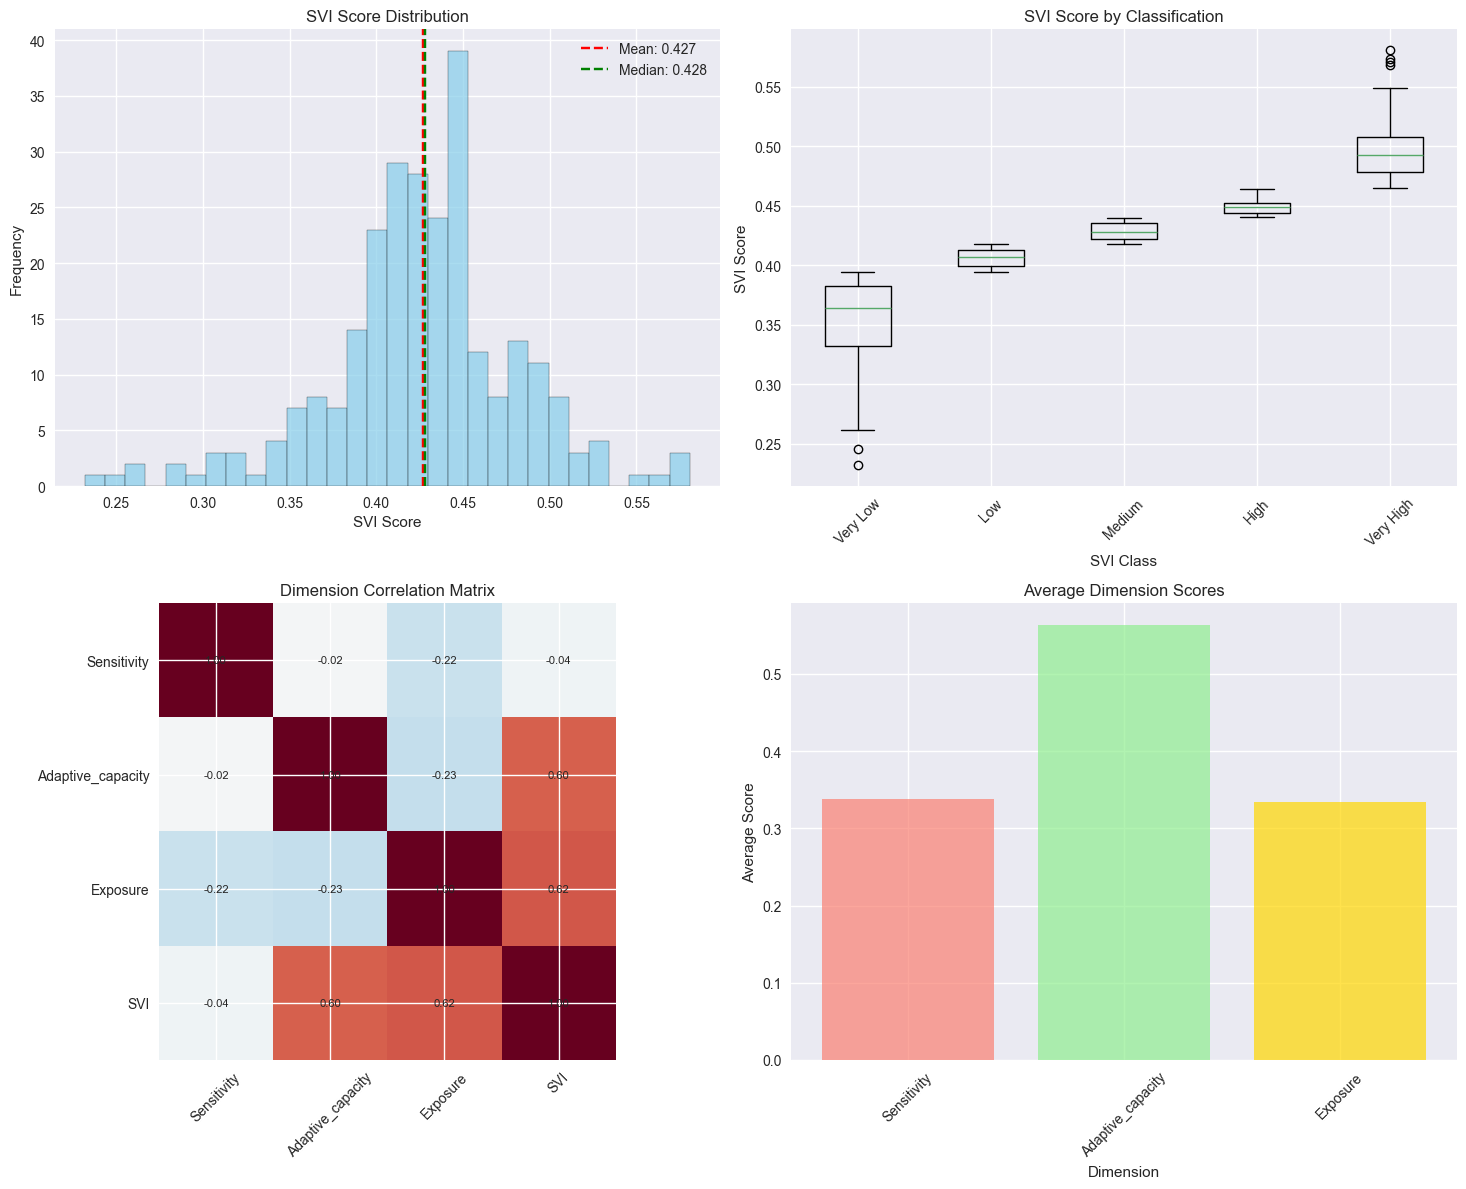

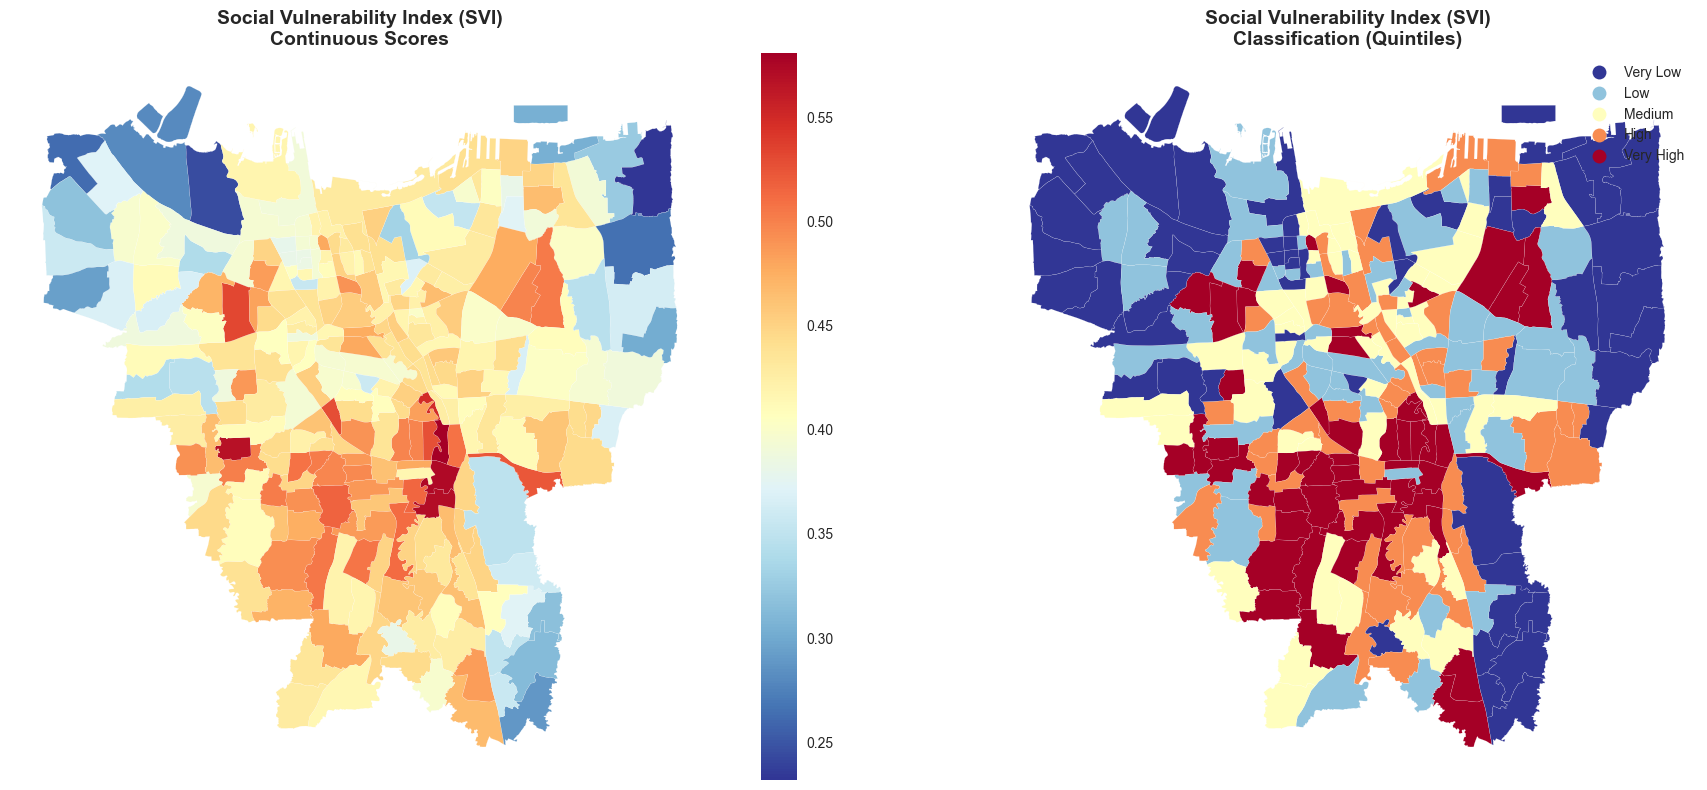

✅ SVI visualizations saved to /Users/nurfaldi/hack4resilient/clean_repo/Barunah-Hack4Resilientjakarta2025/results/svi_multihazard/plots


In [ ]:
# Create comprehensive SVI visualizations
if 'final_svi' in locals() and 'gdf_admin' in locals():
    print("📊 CREATING SVI VISUALIZATIONS")
    print("=" * 40)
    
    # Merge SVI data with boundaries
    # First, ensure we have matching identifiers
    if 'WADMKD' in df_svi.columns and 'WADMKD' in gdf_admin.columns:
        gdf_svi = gdf_admin.merge(df_svi[['WADMKD', 'SVI_Score', 'SVI_Class'] + 
                                        [f'{dim.capitalize()}_Score' for dim in dimension_scores.keys()]], 
                                 on='WADMKD', how='left')
        print(f"✅ Merged {len(gdf_svi)} boundary features with SVI data")
        
        # 1. SVI Distribution Plots
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Histogram of SVI scores
        axes[0,0].hist(final_svi.dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0,0].axvline(final_svi.mean(), color='red', linestyle='--', label=f'Mean: {final_svi.mean():.3f}')
        axes[0,0].axvline(final_svi.median(), color='green', linestyle='--', label=f'Median: {final_svi.median():.3f}')
        axes[0,0].set_title('SVI Score Distribution')
        axes[0,0].set_xlabel('SVI Score')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].legend()
        
        # Box plot by class
        if 'SVI_Class' in df_svi.columns:
            svi_class_data = [df_svi[df_svi['SVI_Class'] == cls]['SVI_Score'].dropna() 
                             for cls in ['Very Low', 'Low', 'Medium', 'High', 'Very High']]
            axes[0,1].boxplot(svi_class_data, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
            axes[0,1].set_title('SVI Score by Classification')
            axes[0,1].set_xlabel('SVI Class')
            axes[0,1].set_ylabel('SVI Score')
            axes[0,1].tick_params(axis='x', rotation=45)
        
        # Dimension correlation
        dimension_cols = [f'{dim.capitalize()}_Score' for dim in dimension_scores.keys()]
        if len(dimension_cols) > 1:
            corr_data = df_svi[dimension_cols + ['SVI_Score']].corr()
            im = axes[1,0].imshow(corr_data, cmap='RdBu_r', vmin=-1, vmax=1)
            axes[1,0].set_xticks(range(len(corr_data.columns)))
            axes[1,0].set_yticks(range(len(corr_data.columns)))
            axes[1,0].set_xticklabels([col.replace('_Score', '') for col in corr_data.columns], rotation=45)
            axes[1,0].set_yticklabels([col.replace('_Score', '') for col in corr_data.columns])
            axes[1,0].set_title('Dimension Correlation Matrix')
            
            # Add correlation values
            for i in range(len(corr_data)):
                for j in range(len(corr_data)):
                    axes[1,0].text(j, i, f'{corr_data.iloc[i,j]:.2f}', 
                                  ha='center', va='center', fontsize=8)
        
        # Dimension contributions
        if len(dimension_scores) > 0:
            dim_means = [df_svi[f'{dim.capitalize()}_Score'].mean() for dim in dimension_scores.keys()]
            dim_names = [dim.capitalize() for dim in dimension_scores.keys()]
            
            axes[1,1].bar(dim_names, dim_means, alpha=0.7, color=['salmon', 'lightgreen', 'gold'])
            axes[1,1].set_title('Average Dimension Scores')
            axes[1,1].set_xlabel('Dimension')
            axes[1,1].set_ylabel('Average Score')
            axes[1,1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig(PLOTS_PATH / 'svi_distribution_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 2. Geographic SVI Map
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # Continuous SVI scores
        gdf_svi.plot(column='SVI_Score', 
                     ax=axes[0],
                     cmap='RdYlBu_r',
                     legend=True,
                     missing_kwds={'color': 'lightgrey'},
                     edgecolor='white',
                     linewidth=0.1)
        axes[0].set_title('Social Vulnerability Index (SVI)\nContinuous Scores', fontsize=14, fontweight='bold')
        axes[0].set_axis_off()
        
        # Categorical SVI classes
        if 'SVI_Class' in gdf_svi.columns:
            class_colors = {'Very Low': '#2166ac', 'Low': '#5aae61', 'Medium': '#fdbf6f', 
                           'High': '#f46d43', 'Very High': '#a50026'}
            
            gdf_svi.plot(column='SVI_Class',
                        ax=axes[1],
                        categorical=True,
                        cmap='RdYlBu_r',
                        legend=True,
                        missing_kwds={'color': 'lightgrey'},
                        edgecolor='white',
                        linewidth=0.1)
            axes[1].set_title('Social Vulnerability Index (SVI)\nClassification (Quintiles)', fontsize=14, fontweight='bold')
            axes[1].set_axis_off()
        
        plt.tight_layout()
        plt.savefig(PLOTS_PATH / 'svi_geographic_maps.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ SVI visualizations saved to {PLOTS_PATH}")
        
        # 3. Individual Dimension Maps
        if len(dimension_cols) > 0:
            fig, axes = plt.subplots(1, len(dimension_cols), figsize=(6*len(dimension_cols), 8))
            
            # Handle case where there's only one dimension
            if len(dimension_cols) == 1:
                axes = [axes]
            
            # Plot each dimension
            for i, dim_col in enumerate(dimension_cols):
                gdf_svi.plot(column=dim_col,
                            ax=axes[i],
                            cmap='RdYlBu_r',
                            legend=True,
                            missing_kwds={'color': 'lightgrey'},
                            edgecolor='white',
                            linewidth=0.1)
                dim_name = dim_col.replace('_Score', '')
                axes[i].set_title(f'{dim_name} Dimension', fontsize=14, fontweight='bold')
                axes[i].set_axis_off()
            
            plt.tight_layout()
            plt.savefig(PLOTS_PATH / 'svi_dimension_maps.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print(f"✅ SVI dimension maps saved to {PLOTS_PATH}")

    else:
        print("❌ Cannot merge SVI data with boundaries - missing matching columns")
        print(f"   DataFrame columns: {[col for col in df_svi.columns if 'WADM' in col]}")
        print(f"   GeoDataFrame columns: {[col for col in gdf_admin.columns if 'WADM' in col]}")

else:
    print("❌ SVI results or boundaries not available for visualization")

In [19]:
# Create a function to plot SVI dimensions
def plot_svi_dimensions(df, svi_columns, title="Social Vulnerability Index Dimensions"):
    """
    Plot SVI dimensions for each kelurahan
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing SVI dimensions
    svi_columns : list
        List of SVI dimension column names
    title : str
        Plot title
    """
    # Create a figure with appropriate size
    plt.figure(figsize=(12, 10))
    
    # Create a heatmap of SVI dimensions
    sns.heatmap(df[svi_columns].sort_values(by=svi_columns[0]), 
                cmap='YlOrRd', 
                annot=False, 
                linewidths=0.5, 
                cbar_kws={'label': 'Vulnerability Score'})
    
    plt.title(title, fontsize=16)
    plt.xlabel('SVI Dimensions', fontsize=12)
    plt.ylabel('Kelurahan (sorted)', fontsize=12)
    plt.tight_layout()
    
    # Save the figure
    # plt.savefig(os.path.join(output_path, 'svi_dimensions_heatmap.png'), dpi=300)
    plt.show()


---
## 🔄 CHECKPOINT 3: SVI Calculation Complete

**Summary of Progress:**
- ✅ SVI indicators processed and normalized
- ✅ Dimension scores calculated
- ✅ Final SVI scores computed
- ✅ Quintile classifications created
- ✅ Comprehensive visualizations generated

**Key Results:**
- SVI calculated for X kelurahan
- Three dimensions integrated: Sensitivity, Adaptive Capacity, Exposure
- Results saved with geographic mapping

**Next Steps:** Multi-hazard risk assessment

---

## Phase 4: Multi-Hazard Risk Assessment (Preview)

### Step 4.1: Save Current Progress and Prepare for Hazard Analysis

In [ ]:
# Save current progress
print("💾 SAVING PROGRESS AND PREPARING FOR NEXT PHASE")
print("=" * 50)

# Save SVI results
if 'df_svi' in locals():
    # Save as CSV
    svi_output_file = OUTPUT_PATH / 'svi_results_kelurahan.csv'
    svi_columns = ['WADMKD', 'WADMKC', 'WADMKK', 'SVI_Score', 'SVI_Class'] + \
                  [f'{dim.capitalize()}_Score' for dim in dimension_scores.keys() if f'{dim.capitalize()}_Score' in df_svi.columns]
    
    available_cols = [col for col in svi_columns if col in df_svi.columns]
    df_svi[available_cols].to_csv(svi_output_file, index=False)
    print(f"✅ SVI results saved to: {svi_output_file}")

# Save geographic SVI data
if 'gdf_svi' in locals():
    svi_geo_file = OUTPUT_PATH / 'svi_results_geographic.geojson'
    gdf_svi.to_file(svi_geo_file, driver='GeoJSON')
    print(f"✅ Geographic SVI data saved to: {svi_geo_file}")

# Create summary report
if 'final_svi' in locals():
    summary_report = f"""
# SVI CALCULATION SUMMARY REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Data Coverage
- Total Kelurahan: {len(df_svi)}
- SVI Calculated: {final_svi.notna().sum()} ({final_svi.notna().sum()/len(df_svi):.1%})

## SVI Statistics
- Minimum Score: {final_svi.min():.4f}
- Maximum Score: {final_svi.max():.4f}
- Mean Score: {final_svi.mean():.4f}
- Median Score: {final_svi.median():.4f}
- Standard Deviation: {final_svi.std():.4f}

## Dimension Contributions
"""
    
    for dimension in dimension_scores.keys():
        if f'{dimension.capitalize()}_Score' in df_svi.columns:
            dim_score = df_svi[f'{dimension.capitalize()}_Score']
            summary_report += f"\n### {dimension.capitalize()}
            summary_report += f"- Weight: {CONFIG['svi_weights'][dimension]:.0%}\n"
            summary_report += f"- Mean Score: {dim_score.mean():.4f}\n"
            summary_report += f"- Valid Data: {dim_score.notna().sum()}/{len(df_svi)} ({dim_score.notna().sum()/len(df_svi):.1%})\n"
    
    if 'svi_classes' in locals():
        summary_report += f"\n## Classification Distribution\n"
        class_counts = svi_classes.value_counts().sort_index()
        for class_name, count in class_counts.items():
            pct = count / final_svi.notna().sum() * 100
            summary_report += f"- {class_name}: {count} kelurahan ({pct:.1f}%)\n"
    
    # Save summary
    summary_file = OUTPUT_PATH / 'svi_summary_report.md'
    with open(summary_file, 'w') as f:
        f.write(summary_report)
    
    print(f"✅ Summary report saved to: {summary_file}")

print(f"\n📊 PHASE 1-3 COMPLETE!")
print(f"\nNext Steps for Multi-Hazard Assessment:")
print(f"1. Load hazard data (flood, heat, subsidence)")
print(f"2. Process and normalize hazard indicators")
print(f"3. Create multi-hazard index")
print(f"4. Combine with SVI for integrated risk assessment")
print(f"5. Generate final risk maps and hotspot analysis")

print(f"\n💡 To continue with hazard assessment, run the next sections or create a new notebook focusing on hazard data processing.")